Several notes on SEI models:
1. In "reaction limited" smallest L_sei_0 can be used is 1e-12.
2. "electron-migration limited" for smalle L_sei_0 produce error and for relatively large L_sei_0 > 4e-9 at some point L_sei decrease. I have noticed tht overpotntial always must be negative [Tang et al. 2012](https://iopscience.iop.org/article/10.1149/2.025211je). So if we make it  postive we get postitive L_sei for any L_sei_0.
3. L_sei in "ec reaction limited" model increase gradually, then nradpidaly, and at some sgate become 

In [1]:
%cd /home/kawamanmi/Projects/PyBaMM
import pybamm
import numpy as np
import matplotlib.pyplot as plt
param = pybamm.ParameterValues("Chen2020")
# param = pybamm.ParameterValues("ORegan2022")

# param

/home/kawamanmi/Projects/PyBaMM


In [16]:
param['Initial inner SEI thickness [m]'] = 1e-10
param['Initial outer SEI thickness [m]'] = 1e-10
# param['Inner SEI open-circuit potential [V]'] = 0.3
# param['Lithium interstitial reference concentration [mol.m-3]'] = 1000
param

{'Ambient temperature [K]': 298.15,
 'Boltzmann constant [J.K-1]': 1.380649e-23,
 'Bulk solvent concentration [mol.m-3]': 2636.0,
 'Cation transference number': 0.2594,
 'Cell cooling surface area [m2]': 0.00531,
 'Cell thermal expansion coefficient [m.K-1]': 1.1e-06,
 'Cell volume [m3]': 2.42e-05,
 'Contact resistance [Ohm]': 0,
 'Current function [A]': 5.0,
 'EC diffusivity [m2.s-1]': 2e-18,
 'EC initial concentration in electrolyte [mol.m-3]': 4541.0,
 'Edge heat transfer coefficient [W.m-2.K-1]': 0.3,
 'Electrode height [m]': 0.065,
 'Electrode width [m]': 1.58,
 'Electrolyte conductivity [S.m-1]': <function electrolyte_conductivity_Nyman2008 at 0x7f24f53e1900>,
 'Electrolyte diffusivity [m2.s-1]': <function electrolyte_diffusivity_Nyman2008 at 0x7f24f53e1870>,
 'Electron charge [C]': 1.602176634e-19,
 'Faraday constant [C.mol-1]': 96485.33212,
 'Ideal gas constant [J.K-1.mol-1]': 8.314462618,
 'Initial concentration in electrolyte [mol.m-3]': 1000.0,
 'Initial concentration in neg

In [21]:
Ds = [6.8*1e-21, 1.3*1e-15, 13.6*1e-21]
kf = [1e-7, 1.36e-12, 3.4e-12]
C_sol = 4541
F = 96485
ia = 4.869
Lsei0 = 1e-12
R = [F * k * C_sol / ia for k in kf]
DD = [F * D * C_sol / (ia*Lsei0) for D in Ds]
print(R)
print(DD)

[8.998529164099404, 0.00012237999663175191, 0.00030594999157937977]
[0.6118999831587594, 116980.87913329228, 1.2237999663175188]


In [3]:

cycle_no = 10


stateOfCharge = 0
exp_CCCV = pybamm.Experiment(
    [("Charge at C/10 until 4.2 V",
      "Rest for 5 hours",
      "Discharge at C/10 until 2.5 V",
      "Rest for 5 hours",
      )] * cycle_no
)

In [4]:

sei_models = ["Kolzenberg2020", "interstitial-diffusion limited",
              "electron-migration limited"]
# sei_models = ["Kolzenberg2020", "interstitial-diffusion limited",
#               "electron-migration limited"]
# sei_models = ["ec reaction limited", "reaction limited",
#               "solvent-diffusion limited", "interstitial-diffusion limited", "electron-migration limited"]
# sei_models = ["reaction limited",
#   "ec reaction limited", "solvent-diffusion limited"]


name_models = ["SPM"]
models_SPM = [pybamm.lithium_ion.DFN(options={
    "SEI": sei_models[index],
    "SEI porosity change": "true",
    # "SEI film resistance": "distributed",
    # "total interfacial current density as a state": "true",



},
    name=sei_models[index]) for index in range(len(sei_models))
]

In [5]:

models_SPM[0].variable_names()
pybamm.settings.max_y_value = 100000000

In [6]:
models_SPM[0].variable_names()

['Time [s]',
 'Time [min]',
 'Time [h]',
 'x [m]',
 'x_n [m]',
 'x_s [m]',
 'x_p [m]',
 'r_n [m]',
 'r_p [m]',
 'Current variable [A]',
 'Total current density [A.m-2]',
 'Current [A]',
 'C-rate',
 'Discharge capacity [A.h]',
 'Throughput capacity [A.h]',
 'Discharge energy [W.h]',
 'Throughput energy [W.h]',
 'Negative electrode interface utilisation variable',
 'X-averaged negative electrode interface utilisation variable',
 'Negative electrode interface utilisation',
 'X-averaged negative electrode interface utilisation',
 'Positive electrode interface utilisation variable',
 'X-averaged positive electrode interface utilisation variable',
 'Positive electrode interface utilisation',
 'X-averaged positive electrode interface utilisation',
 'Negative particle crack length [m]',
 'X-averaged negative particle crack length [m]',
 'Negative particle cracking rate [m.s-1]',
 'X-averaged negative particle cracking rate [m.s-1]',
 'Positive particle crack length [m]',
 'X-averaged positive 

In [7]:

# please note that the size of sims will be equal to the number of models times the number of experiments
from pybamm.models import event


solver = pybamm.CasadiSolver(mode="safe")
# solver = pybamm.ScipySolver(atol=1e-8, rtol=1e-8)
# solver = pybamm.IDAKLUSolver()
sims_SPM = [pybamm.Simulation(model, parameter_values=param,
                              experiment=exp_CCCV, solver=solver) for model in models_SPM]

In [8]:
sols_SPM = [sim.solve(initial_soc=stateOfCharge) for sim in sims_SPM]

At t = 481.225, , mxstep steps taken before reaching tout.
2024-03-07 11:48:43.624 - [WARNING] callbacks.on_experiment_infeasible(231): 

	Experiment is infeasible: 'event: Zero negative electrode porosity cut-off' was triggered during 'Charge at C/10 until 4.2 V'. The returned solution only contains up to step 1 of cycle 1. 


In [9]:
# Vaiables to be postprocessed, you can add as many as output variables to the following list
# you can find the list variables to be be output by typing model name dot varaible_name() e.g. here, models[0].variable_names()
out_vars = [  # 'X-averaged negative particle surface concentration [mol.m-3]',
    # "Voltage [V]",
    # 'X-averaged negative SEI thickness [m]',
    'Discharge capacity [A.h]'
    # 'Total capacity lost to side reactions [A.h]',
    # 'Loss of lithium to SEI [mol]',
    'Total current density [A.m-2]',
    # 'X-averaged outer SEI thickness [m]',
    # 'X-averaged negative electrode porosity',
]

# Label for the output variables y-axis in the plots
yaxis_labels = ["SEI_thickness",
                'Total capacity lost to side reactions [A.h]', 'Total lithium in particles', 'X-averaged inner SEI thickness [m]',
                'X-averaged outer SEI thickness [m]',]

In [10]:
# from matplotlib import lines

# for sol in sols_SPM:  # loop through the solutions of the DFN models
#     LS_cycles = [sol.cycles[k].steps[2]['X-averaged SEI thickness [m]'].entries[-1]
#                  for k in range(cycle_no)]
#     plt.scatter(np.arange(1, cycle_no+1), LS_cycles,
#                 label=models_SPM[sols_SPM.index(sol)].name)
# plt.xlabel("Cycle number")
# plt.ylabel("SEI thickness [m]")
# plt.legend()
# plt.show()

kk
kk


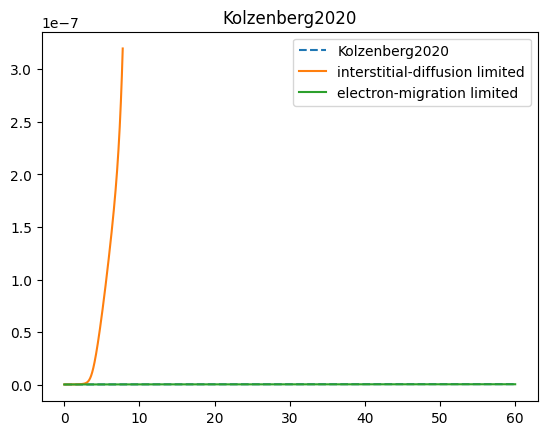

In [11]:
# plt.plot(sols_SPM[0].t, sols_SPM[0]
#          ['X-averaged negative electrode SEI interfacial current density [A.m-2]'].entries)
# plt.show()

dd = len(sei_models)
# print(dd)
# for j in range(dd):
#     plt.plot(sols_SPM[j].t/3600, sols_SPM[j]
#              ['X-averaged negative electrode SEI interfacial current density [A.m-2]'].entries, label=models_SPM[j].name)
# plt.legend()
# plt.show()

# for j in range(dd):
#     if (j == dd):
#         plt.plot(sols_SPM[j].t/3600, sols_SPM[j]
#                  ['X-averaged negative electrode SEI film overpotential [V]'].entries, label=models_SPM[j].name)
#     else:
#         plt.plot(sols_SPM[j].t/3600, sols_SPM[j]
#                  ['X-averaged negative electrode SEI film overpotential [V]'].entries, label=models_SPM[j].name)
# plt.legend()
# plt.show()

# for j in range(dd):
#     # if (j == dd-2):
#     #     plt.plot(sols_SPM[j].t/3600, sols_SPM[j]
#     #              ['X-averaged negative total SEI thickness [m]'].entries, label=models_SPM[j].name + "/100")
#     # else:
#     plt.plot(sols_SPM[j].t/3600, sols_SPM[j]
#              ['X-averaged negative electrode SEI film overpotential [V]'].entries, label="Eta_SEI")
#     # # plt.plot(sols_SPM[j].t/3600, sols_SPM[j]
#     # #          ['X-averaged negative total SEI thickness [m]'].entries*100000, label=models_SPM[j].name)
#     # plt.plot(sols_SPM[j].t/3600, sols_SPM[j]
#     #          ['X-averaged negative electrode SEI interfacial current density [A.m-2]'].entries*100, label="J_SEI/100")
#     plt.plot(sols_SPM[j].t/3600, sols_SPM[j]
#              ['X-averaged negative total SEI thickness [m]'].entries, label="L_SEI/100")

fig, ax1 = plt.subplots()
for j in range(dd):
    if (j == 0):
        ax1.plot(sols_SPM[j].t/3600, sols_SPM[j]
                 ['X-averaged negative total SEI thickness [m]'].entries*1, label=sei_models[j], linestyle='dashed')
    else:
        ax1.plot(sols_SPM[j].t/3600, sols_SPM[j]
                 ['X-averaged negative total SEI thickness [m]'].entries, label=sei_models[j])
        print("kk")

lines, labels = ax1.get_legend_handles_labels()
ax1.legend()
ax1.title.set_text(sei_models[0])
plt.show()

# fig, ax1 = plt.subplots()
# ax2 = ax1.twinx()
# for j in range(dd):
#     if (j == 0):
#         ax1.plot(sols_SPM[j].t/3600, sols_SPM[j]
#                  ['X-averaged negative electrode interfacial current density [A.m-2]'].entries*1, label=sei_models[j])
#     else:
#         ax1.plot(sols_SPM[j].t/3600, sols_SPM[j]
#                  ['X-averaged negative electrode interfacial current density [A.m-2]'].entries, label=sei_models[j])

#     ax2.set_ylabel('L_SEI', color='green')
#     ax2.tick_params(axis='y', labelcolor='green')

# lines, labels = ax1.get_legend_handles_labels()
# lines2, labels2 = ax2.get_legend_handles_labels()
# ax2.legend(lines + lines2, labels + labels2, loc='upper right')
# ax2.title.set_text(sei_models[0])
# plt.show()

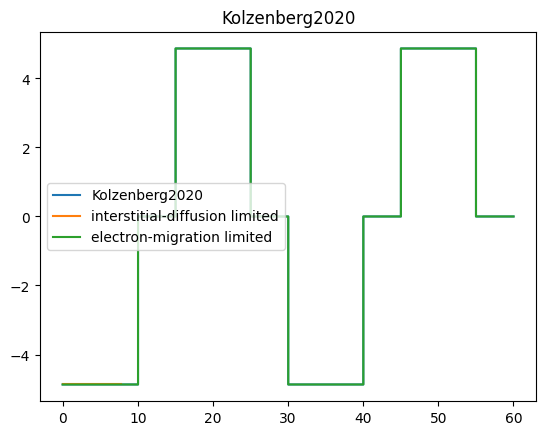

In [12]:
fig, ax1 = plt.subplots()
for j in range(dd):
    ax1.plot(sols_SPM[j].t/3600, sols_SPM[j]
             ['Total current density [A.m-2]'].entries, label=sei_models[j])

lines, labels = ax1.get_legend_handles_labels()
ax1.legend()
ax1.title.set_text(sei_models[0])
plt.show()

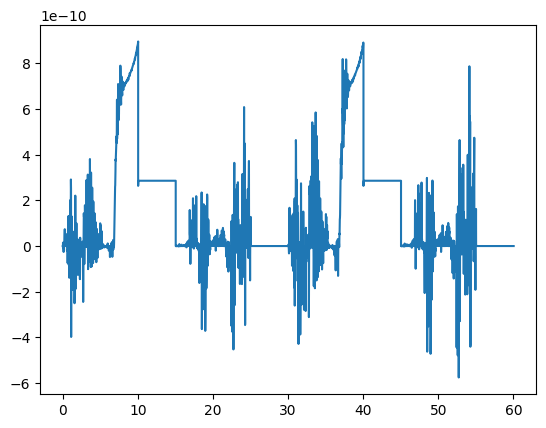

In [13]:
kk = 5
dd1 = sols_SPM[j]['Negative electrode potential [V]'].entries[kk] - \
    sols_SPM[j]['Negative electrolyte potential [V]'].entries[kk]
dd2 = sols_SPM[j]['Negative electrode surface potential difference [V]'].entries[kk]

j0 = sols_SPM[j]["Negative electrode exchange current density [A.m-2]"].entries[kk]
jj = sols_SPM[j]['Negative electrode interfacial current density [A.m-2]'].entries[kk]
F = 96485.33212
R = 8.314462618
T = 298.15
OCP_n = sols_SPM[j]["Negative electrode open-circuit potential [V]"].entries[kk]
L_sei = sols_SPM[j]['Negative total SEI thickness [m]'].entries[kk]
R_sei = 200000.0
U_sei = 0.4
jjsei = sols_SPM[j]['Negative electrode SEI interfacial current density [A.m-2]'].entries[kk]
eta_av = sols_SPM[j]['Negative electrode reaction overpotential [V]'].entries[kk]
eta_int = 2.0*(R*T)/F*np.arcsinh((jj)/(2.0*j0))
plt.plot(sols_SPM[j].t/3600,  eta_int - dd1 +
         OCP_n + jj * R_sei * L_sei, label="Eta_int")

3611
3611
3611
8.631350192557447e-05


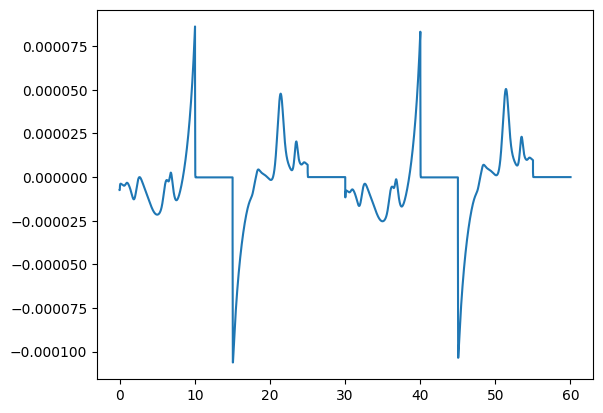

In [14]:
dd = sols_SPM[j]['X-averaged negative electrode potential [V]'].entries - \
    sols_SPM[j]['X-averaged negative electrolyte potential [V]'].entries
#     sols_SPM[j]['X-averaged negative electrode surface potential difference [V]'].entries
dd = sols_SPM[j]['X-averaged negative electrode surface potential difference [V]'].entries
j0 = sols_SPM[j]["X-averaged negative electrode exchange current density [A.m-2]"].entries
jj = sols_SPM[j]['X-averaged negative electrode interfacial current density [A.m-2]'].entries
F = 96485.33212
R = 8.314462618
T = 298.15
OCP_n = sols_SPM[j]["X-averaged negative electrode open-circuit potential [V]"].entries
L_sei = sols_SPM[j]['X-averaged negative total SEI thickness [m]'].entries
R_sei = 200000.0
U_sei = 0.4


eta_av = sols_SPM[j]['X-averaged negative electrode reaction overpotential [V]'].entries
# # L. v. Kolzenberg, ChemSusChem 2020 (eq. 25)
jjsei = sols_SPM[j]['X-averaged negative electrode SEI interfacial current density [A.m-2]'].entries

eta_int = 2*(R*T)/F*np.arcsinh((jj + jjsei*0)/(2.0*j0))
plt.plot(sols_SPM[j].t/3600, eta_int - eta_av +
         jj * R_sei * L_sei, label="Eta_int")
print(np.size(j0))
print(np.size(jj))
print(np.size(dd))
print(np.max(eta_int - eta_av + jj * R_sei * L_sei))

TypeError: only integer scalar arrays can be converted to a scalar index

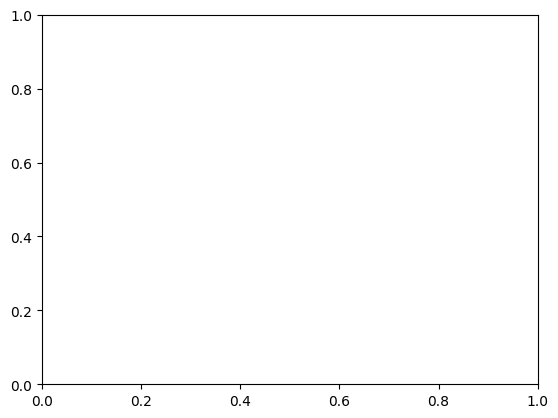

In [15]:
fig, ax1 = plt.subplots()
for j in range(dd):
    ax1.plot(sols_SPM[j].t/3600, sols_SPM[j]
             ['X-averaged negative electrode interfacial current density [A.m-2]'].entries*1, label=sei_models[j], linestyle='dashed')


lines, labels = ax1.get_legend_handles_labels()
ax1.legend()
ax1.title.set_text(sei_models[0])
plt.show()

In [ ]:


for j in range(cycle_no):
    for sol in sols_SPM:  # loop through the solutions of the DFN models
        total_capacity_lost = sol.cycles[j]['Total capacity lost to side reactions [A.h]'].entries
        L_sei = sol.cycles[j]['X-averaged negative total SEI thickness [m]'].entries
        # print(L_sei[-1] - L_sei[0])
        # plt.plot(sol.cycles[j]["Time [h]"].entries, total_capacity_lost,
        #          label=sei_models[sols_SPM.index(sol)] + "Cycle " + str(j+1))
        plt.scatter(sol.cycles[j]["Time [h]"].entries, sol.cycles[j]["Total current density [A.m-2]"].entries,
                    label=sei_models[sols_SPM.index(sol)] + "Cycle " + str(j+1))
plt.xlabel("Time [h]")
plt.ylabel("Capacity lost [A.h]")
plt.legend()
# plt.title("Cycle " + sei_models[sols_SPM.index(sol)])
plt.show()

In [ ]:
from pyparsing import line


line_style = ["-", ":", "--", "-.", "-"]
LL_SEIs = []
Dcs = []
for sol in sols_SPM:  # loop through the solutions of the DFN models
    for j in range(cycle_no):
        negative_current_indices = sol.cycles[j]['Current [A]'].entries > 0
        SoC = sol.cycles[j]['Throughput capacity [A.h]'].entries[negative_current_indices]
        vol = sol.cycles[j]["Voltage [V]"].entries[negative_current_indices]
        L_sei = sol.cycles[j]['X-averaged negative total SEI thickness [m]'].entries
        LL_SEIs.append(L_sei[-1] - L_sei[0])
        Dc = sol.cycles[j]['Discharge capacity [A.h]'].entries
        Dcs.append((SoC[-1]-SoC[0])/5*100)
        # negative_current_indices = sol.cycles[j]['Current [A]'].entries < 0
        # SoC = sol.cycles[j]['Discharge capacity [A.h]'].entries[negative_current_indices]
        # vol = sol.cycles[j]["Voltage [V]"].entries[negative_current_indices]
        plt.plot(SoC-SoC[0], vol,
                 label=sei_models[sols_SPM.index(sol)] + " cycle " + str(j+1), linestyle=line_style[j])
plt.xlabel('Throughput capacity [A.h]', fontsize=14)
plt.ylabel("Voltage [V]", fontsize=14)
# plt.legend()
# plt.title("Cycle " + sei_models[sols_SPM.index(sol)])
plt.show()

kk = 0
marker = ["o", "x", "s", "D", "v"]
# Create a list of distinct colors
colors = plt.cm.plasma(np.linspace(0, 1, len(sols_SPM)))

jj = np.arange(1, cycle_no + 1)
k1 = 0
k2 = len(jj)

for idx, sol in enumerate(sols_SPM):
    # Check if it's the last sol
    capitalized_label = sei_models[sols_SPM.index(sol)].title()
    if idx == 0:
        plt.scatter(jj, np.array(LL_SEIs[k1:k2]) / 100 * 1e9,
                    label=capitalized_label + " / 100",
                    marker=marker[sols_SPM.index(sol)],
                    color=colors[sols_SPM.index(sol)])
    elif idx == len(sols_SPM)-2 or idx == len(sols_SPM)-1:
        plt.scatter(jj, np.array(LL_SEIs[k1:k2])*10 * 1e9,
                    label=capitalized_label + " x 10",
                    marker=marker[sols_SPM.index(sol)],
                    color=colors[sols_SPM.index(sol)])
    else:
        plt.scatter(jj, np.array(LL_SEIs[k1:k2]) * 1e9,
                    label=capitalized_label,
                    marker=marker[sols_SPM.index(sol)],
                    color=colors[sols_SPM.index(sol)])

    k1 = k1 + cycle_no
    k2 = k2 + cycle_no

# Add a legend to the plot
plt.legend(fontsize=12)
plt.ylabel("Increment Length SEI [nm]", fontsize=12)
plt.xlabel("Cycle Number", fontsize=12)
plt.xticks(np.arange(1, cycle_no+1, 1), fontsize=12)
plt.yticks(np.arange(0, 5, 1), fontsize=12)
plt.savefig('/home/kawamanmi/Projects/figure.svg',
            format='svg', dpi=300, bbox_inches='tight')
plt.show()


jj = np.arange(1, cycle_no + 1)
k1 = 0
k2 = len(jj)

for idx, sol in enumerate(sols_SPM):
    # Check if it's the last sol
    capitalized_label = sei_models[sols_SPM.index(sol)].title()
    if idx == 0:
        plt.scatter((100-np.array(Dcs[k1:k2]))-10, np.array(LL_SEIs[k1:k2])/1 * 1e9,
                    label=capitalized_label + " x 10",
                    marker=marker[sols_SPM.index(sol)],
                    color=colors[sols_SPM.index(sol)])
    elif idx == len(sols_SPM)-2 or idx == len(sols_SPM)-1:
        plt.scatter(100-np.array(Dcs[k1:k2]), np.array(LL_SEIs[k1:k2]) * 1e9,
                    label=capitalized_label + " x 10",
                    marker=marker[sols_SPM.index(sol)],
                    color=colors[sols_SPM.index(sol)])
    else:
        plt.scatter(100 - np.array(Dcs[k1:k2]), np.array(LL_SEIs[k1:k2]) * 1e9,
                    label=capitalized_label,
                    marker=marker[sols_SPM.index(sol)],
                    color=colors[sols_SPM.index(sol)])

    k1 = k1 + cycle_no
    k2 = k2 + cycle_no
    plt.legend()
plt.ylabel("Increment Length SEI [nm]", fontsize=14)
plt.xlabel("Cycle Number")
plt.xticks(np.arange(1, cycle_no+1, 1))
plt.yticks(np.arange(0, 5, 1))
plt.show()
print(Dcs)

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np

# # Create a figure and axis for the main plot
fig, ax_main = plt.subplots()

# # Loop through cycles and solutions
for sol in sols_SPM:
    for j in range(cycle_no):
        negative_current_indices = sol.cycles[j]['Current [A]'].entries > 0
        SoC = sol.cycles[j]['Discharge capacity [A.h]'].entries[negative_current_indices]
        vol = sol.cycles[j]["Voltage [V]"].entries[negative_current_indices]
        print(np.abs(SoC[0]) / 5 * 100)
        ax_main.plot(np.abs(SoC) / 5 * 100, vol,
                     label=sei_models[sols_SPM.index(sol)] + " cycle " + str(j + 1))

# Set labels and legend for the main plot
ax_main.set_xlabel("SOC [%]")
ax_main.set_ylabel("Voltage [V]")
ax_main.legend()

# # Create a subplot for magnification
# # Adjust the coordinates and size as needed
# ax_magnify = plt.axes([0.2, 0.6, 0.25, 0.25])

# # Plot the magnified section (voltage between 2.5 and 2.75)

# for sol in sols_SPM:
#     for j in range(cycle_no):
#         negative_current_indices = sol.cycles[j]['Current [A]'].entries < 0
#         SoC = sol.cycles[j]['Discharge capacity [A.h]'].entries[negative_current_indices]
#         vol = sol.cycles[j]["Voltage [V]"].entries[negative_current_indices]

#         # Only plot the desired voltage range in the magnified subplot
#         voltage_range_mask = (vol >= 2.5) & (vol <= 2.75)
#         ax_magnify.plot(np.abs(SoC[voltage_range_mask]) /
#                         5 * 100, vol[voltage_range_mask])

# # Set labels for the magnified subplot
# ax_magnify.set_xlabel("SOC [%]")
# ax_magnify.set_ylabel("Voltage [V]")
# ax_magnify.set_title("Magnified View (Voltage between 2.5 and 2.75)")

# # Show the plots
# plt.show()

In [ ]:
# from matplotlib import lines


# for out_var in out_vars:  # Loop through the output variables
#     for sol in sols_SPM:  # loop through the solutions of the SPM models
#         plt.plot(sol['Time [h]'].entries, sol[out_var].entries,
#                  linestyle='--',
#                  label=models_SPM[sols_SPM.index(sol)].name)

#     plt.xlabel("Time [h]")
#     plt.ylabel(yaxis_labels[out_vars.index(out_var)])
#     plt.legend()
#     plt.show()

In [ ]:
import pybamm
import numpy as np

parameter_values = pybamm.ParameterValues("Chen2020")
model = pybamm.lithium_ion.SPMe()
experiment = pybamm.Experiment(["Discharge at 1C until 3 V"])

sim = pybamm.Simulation(
    parameter_values=parameter_values,
    model=model,
    experiment=experiment
)
sol = sim.solve()

print(
    np.max(
        np.abs(sol["Voltage [V]"].entries - (sol["Positive current collector potential [V]"].entries -
               sol["Negative current collector potential [V]"].entries))
    )
)

In [ ]:
import matplotlib.pyplot as plt
plt.plot(sol["Time [h]"].entries, sol["Voltage [V]"].entries)

In [ ]:
pybamm.plot_voltage_components(sol, split_by_electrode=True)